# Common Libraries

In [1]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [3]:
def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = mujoco.MjData(model)
    data_copy.qpos = data.qpos.copy()
    data_copy.qvel = data.qvel.copy()
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy.qfrc_inverse

# Params

In [6]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/scaled_model/scaled_model_cvt3_mocap.xml"

# Simulation params
n_times = 100

# PD control
kp = 500.0  # Stiffness
kv = 50.0   # Damping

# Initialize model

In [7]:
pd_model = mujoco.MjModel.from_xml_path(model_path)
mj_model = mujoco.MjModel.from_xml_path(model_path)

# Model constants
joint_names = [mujoco.mj_id2name(pd_model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(pd_model.njnt)]
n_joint = len(joint_names)

# Joint indexing
key_name = "default-pose"
key_id = mujoco.mj_name2id(pd_model, mujoco.mjtObj.mjOBJ_KEY, key_name)
key_qpos = pd_model.key_qpos[key_id]
interest_joint_names = joint_names
goal_angle_map = {}
for joint_name in interest_joint_names:
    goal_angle_map[joint_name] = key_qpos[joint_names.index(joint_name)]

interest_joint_map = {}
for joint_name in interest_joint_names:
    jnt_id = pd_model.joint(joint_name).id
    qpos_idx = pd_model.jnt_qposadr[jnt_id]
    dof_idx = pd_model.jnt_dofadr[jnt_id]
    
    interest_joint_map[joint_name] = {
        "joint_id" : jnt_id,
        "qposadr" : qpos_idx,
        "dofadr" : dof_idx,
        "goal_angle" : goal_angle_map[joint_name],
    }

interest_joint_ids = [interest_joint_map[name]["joint_id"] for name in interest_joint_names]
interest_joint_ids = np.array(interest_joint_ids)

# Initialize pose
pd_data = mujoco.MjData(pd_model)
mujoco.mj_forward(pd_model, pd_data)

mj_data = mujoco.MjData(mj_model)
mujoco.mj_forward(mj_model, mj_data)

# Renderer

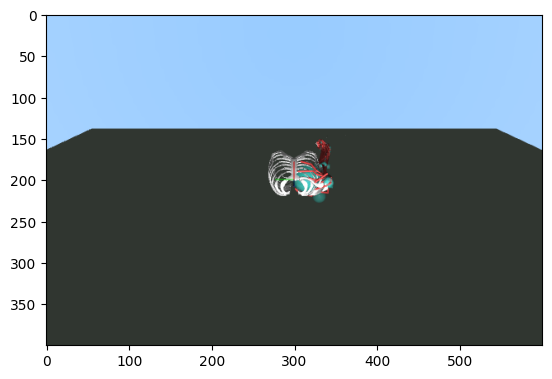

In [8]:
# Renderer
pd_renderer = mujoco.Renderer(pd_model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Initial render
pd_renderer.update_scene(pd_data, camera=camera, scene_option=scene_option)
plt.imshow(pd_renderer.render())

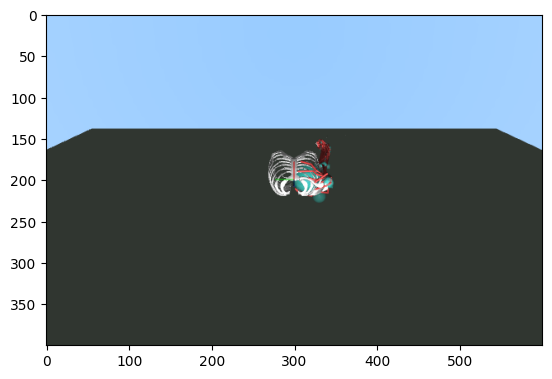

In [9]:
# Renderer
mj_renderer = mujoco.Renderer(mj_model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Initial render
mj_renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(mj_renderer.render())

# Simulation

If model.opt.timestep is big, the simulation not works well. 

When you want to control multipl joints, you need to set the model.opt.timestep with smaller value.

In case of controlling 20 joints including independent and dependent joints, You need to set the timestep as 0.0001

In [10]:
opt_timestep = 0.0001
pd_model.opt.timestep = opt_timestep
mj_model.opt.timestep = opt_timestep

In [11]:
# Initialize start pose
pd_data = mujoco.MjData(pd_model)
mj_data = mujoco.MjData(mj_model)

mujoco.mj_forward(pd_model, pd_data)
mujoco.mj_forward(mj_model, mj_data)

# Goal
final_goal_qpos = pd_data.qpos.copy()
for joint_name in interest_joint_map:
    joint_i = interest_joint_map[joint_name]["joint_id"]
    final_goal_qpos[joint_i] = interest_joint_map[joint_name]["goal_angle"]

# Simulation Constants
times = np.arange(n_times) * opt_timestep

# Pixel
pd_pixels = np.zeros((n_times, pd_renderer.height, pd_renderer.width, 3), dtype = np.uint8)
mj_pixels = np.zeros((n_times, mj_renderer.height, mj_renderer.width, 3), dtype = np.uint8)

# History
pd_qpos = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
pd_qpos.columns = ["time"] + joint_names

mj_qpos = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
mj_qpos.columns = ["time"] + joint_names

pd_qforces = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
pd_qforces.columns = ["time"] + joint_names

mj_qforces = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
mj_qforces.columns = ["time"] + joint_names

# Error
pd_qerrors = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
pd_qerrors.columns = ["time"] + joint_names

mj_qerrors = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
mj_qerrors.columns = ["time"] + joint_names

# Simulation
for time_i in tqdm(range(n_times)):
    time = times[time_i]
    
    # Current
    pd_current_qpos = pd_data.qpos.copy()
    pd_current_qvel = pd_data.qvel.copy()

    mj_current_qpos = mj_data.qpos.copy()
    mj_current_qvel = mj_data.qvel.copy()
    
    # PD Control
    pd_error_q = np.zeros_like(pd_data.qpos)
    pd_error_q[interest_joint_ids] = final_goal_qpos[interest_joint_ids] - pd_current_qpos[interest_joint_ids]
    
    pd_error_v = np.zeros_like(pd_data.qpos)
    pd_error_v[interest_joint_ids] = 0 - pd_current_qvel[interest_joint_ids]
    
    pd_tau_all = np.zeros(pd_model.nv)
    pd_tau_all = kp * pd_error_q + kv * pd_error_v
    pd_data.qfrc_applied[:] = pd_tau_all

    pd_qpos.iloc[time_i] = np.hstack([time, pd_current_qpos])
    pd_qerrors.iloc[time_i] = np.hstack([time, pd_error_q])
    pd_qforces.iloc[time_i] = np.hstack([time, pd_tau_all])

    # mj inverse
    mj_error_q = np.zeros_like(mj_data.qpos)
    mj_error_q[interest_joint_ids] = final_goal_qpos[interest_joint_ids] - mj_current_qpos[interest_joint_ids]
    
    mj_tau_all = get_qfrc(mj_model, mj_data, final_goal_qpos)
    mj_data.qfrc_applied[:] = mj_tau_all

    mj_qpos.iloc[time_i] = np.hstack([time, mj_current_qpos])
    mj_qerrors.iloc[time_i] = np.hstack([time, mj_error_q])
    mj_qforces.iloc[time_i] = np.hstack([time, mj_tau_all])
    
    # Forward dyanmics
    mujoco.mj_step(pd_model, pd_data)
    mujoco.mj_step(mj_model, mj_data)
    
    # Rendering
    pd_renderer.update_scene(pd_data, camera = camera, scene_option = scene_option)
    mj_renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pd_pixels[time_i] = pd_renderer.render()
    mj_pixels[time_i] = mj_renderer.render()

100%|██████████| 100/100 [00:01<00:00, 72.64it/s]


In [12]:
mediapy.show_video(pd_pixels, fps = 30)

In [13]:
mediapy.show_video(mj_pixels, fps = 30)

This browser does not support the video tag.


# Error plot

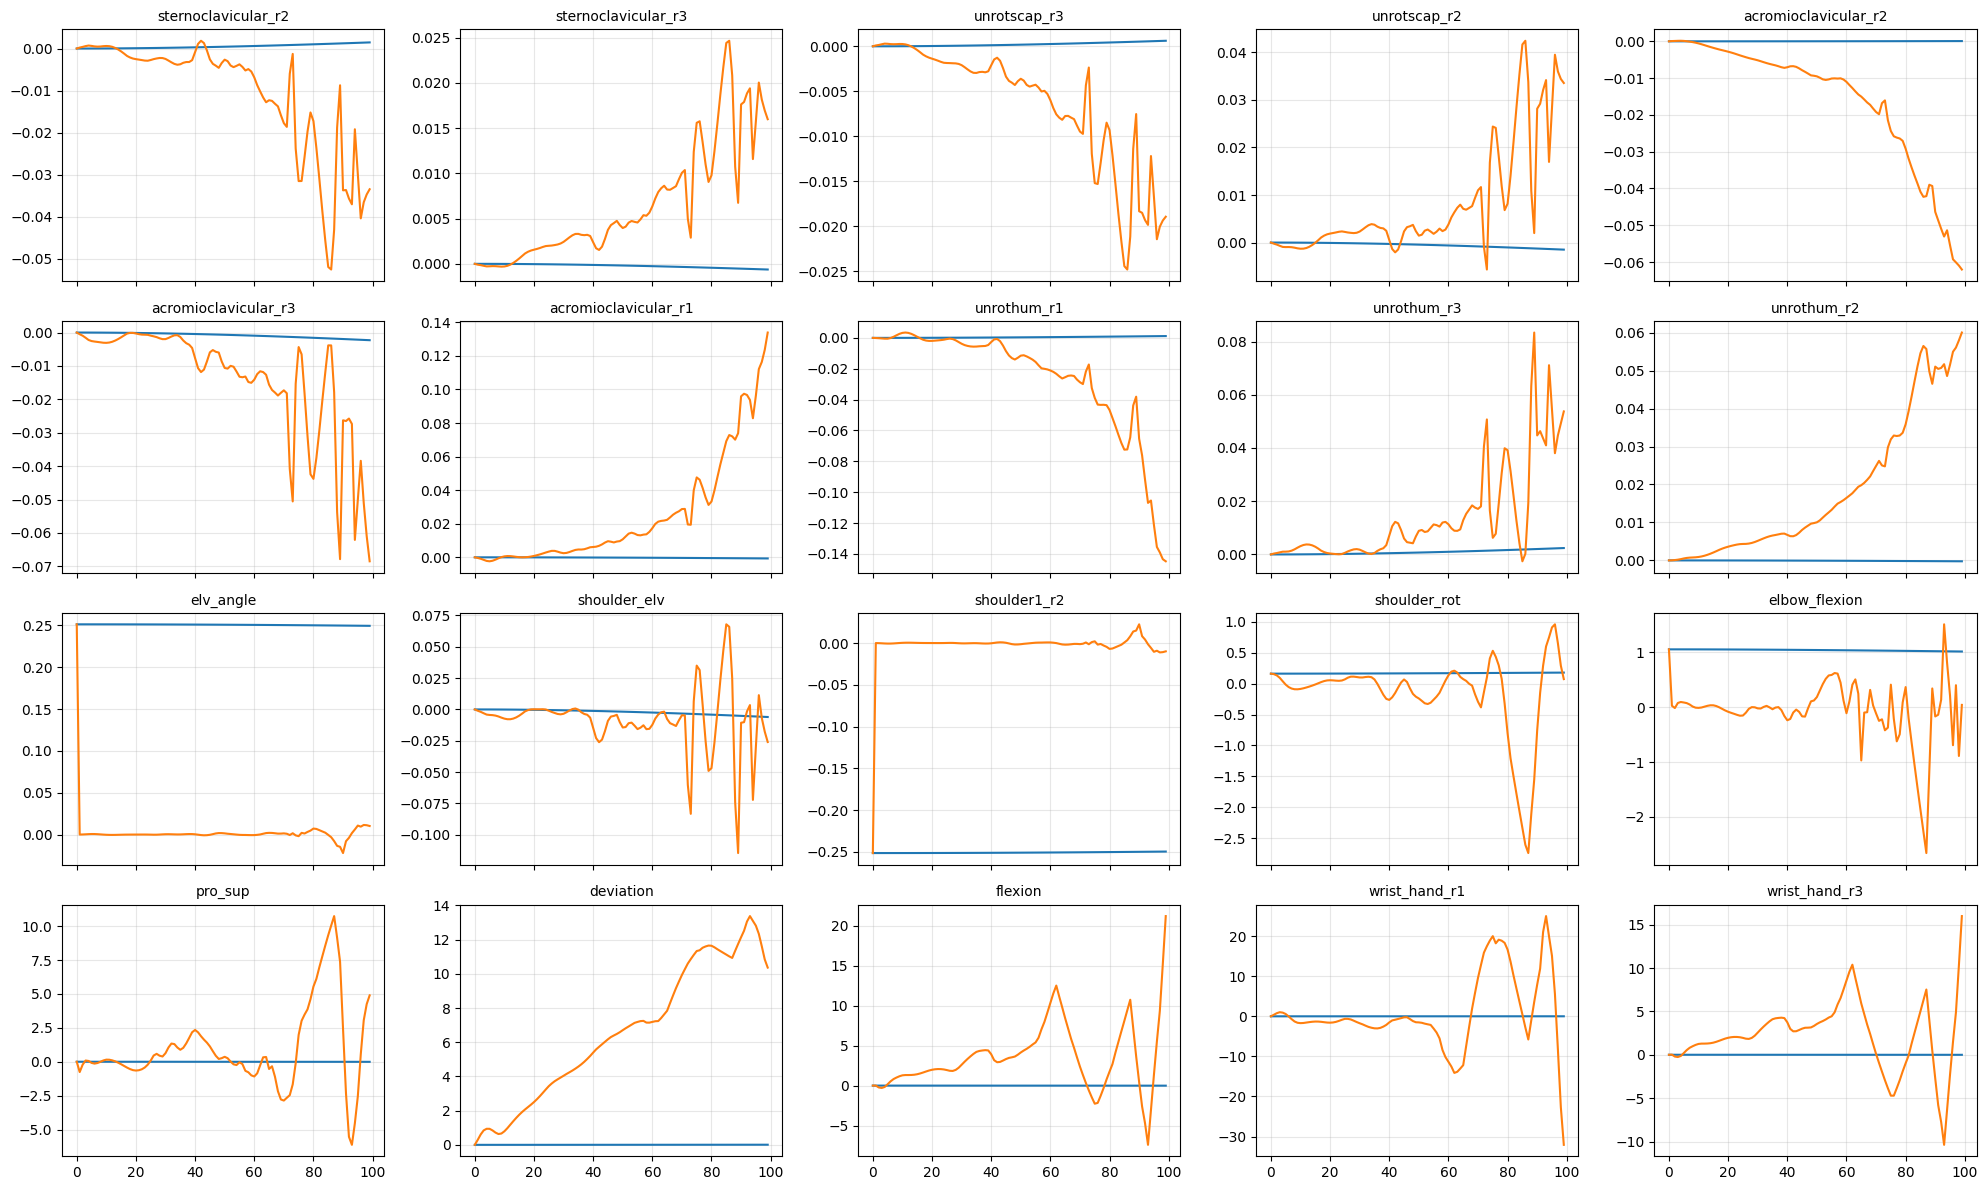

In [14]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(pd_qerrors[joint_name], lw = 1.5, label = "pd control")
    ax.plot(mj_qerrors[joint_name], lw = 1.5, label = "mj inverse")
    ax.set_title(joint_name, fontsize = 10)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Force plot

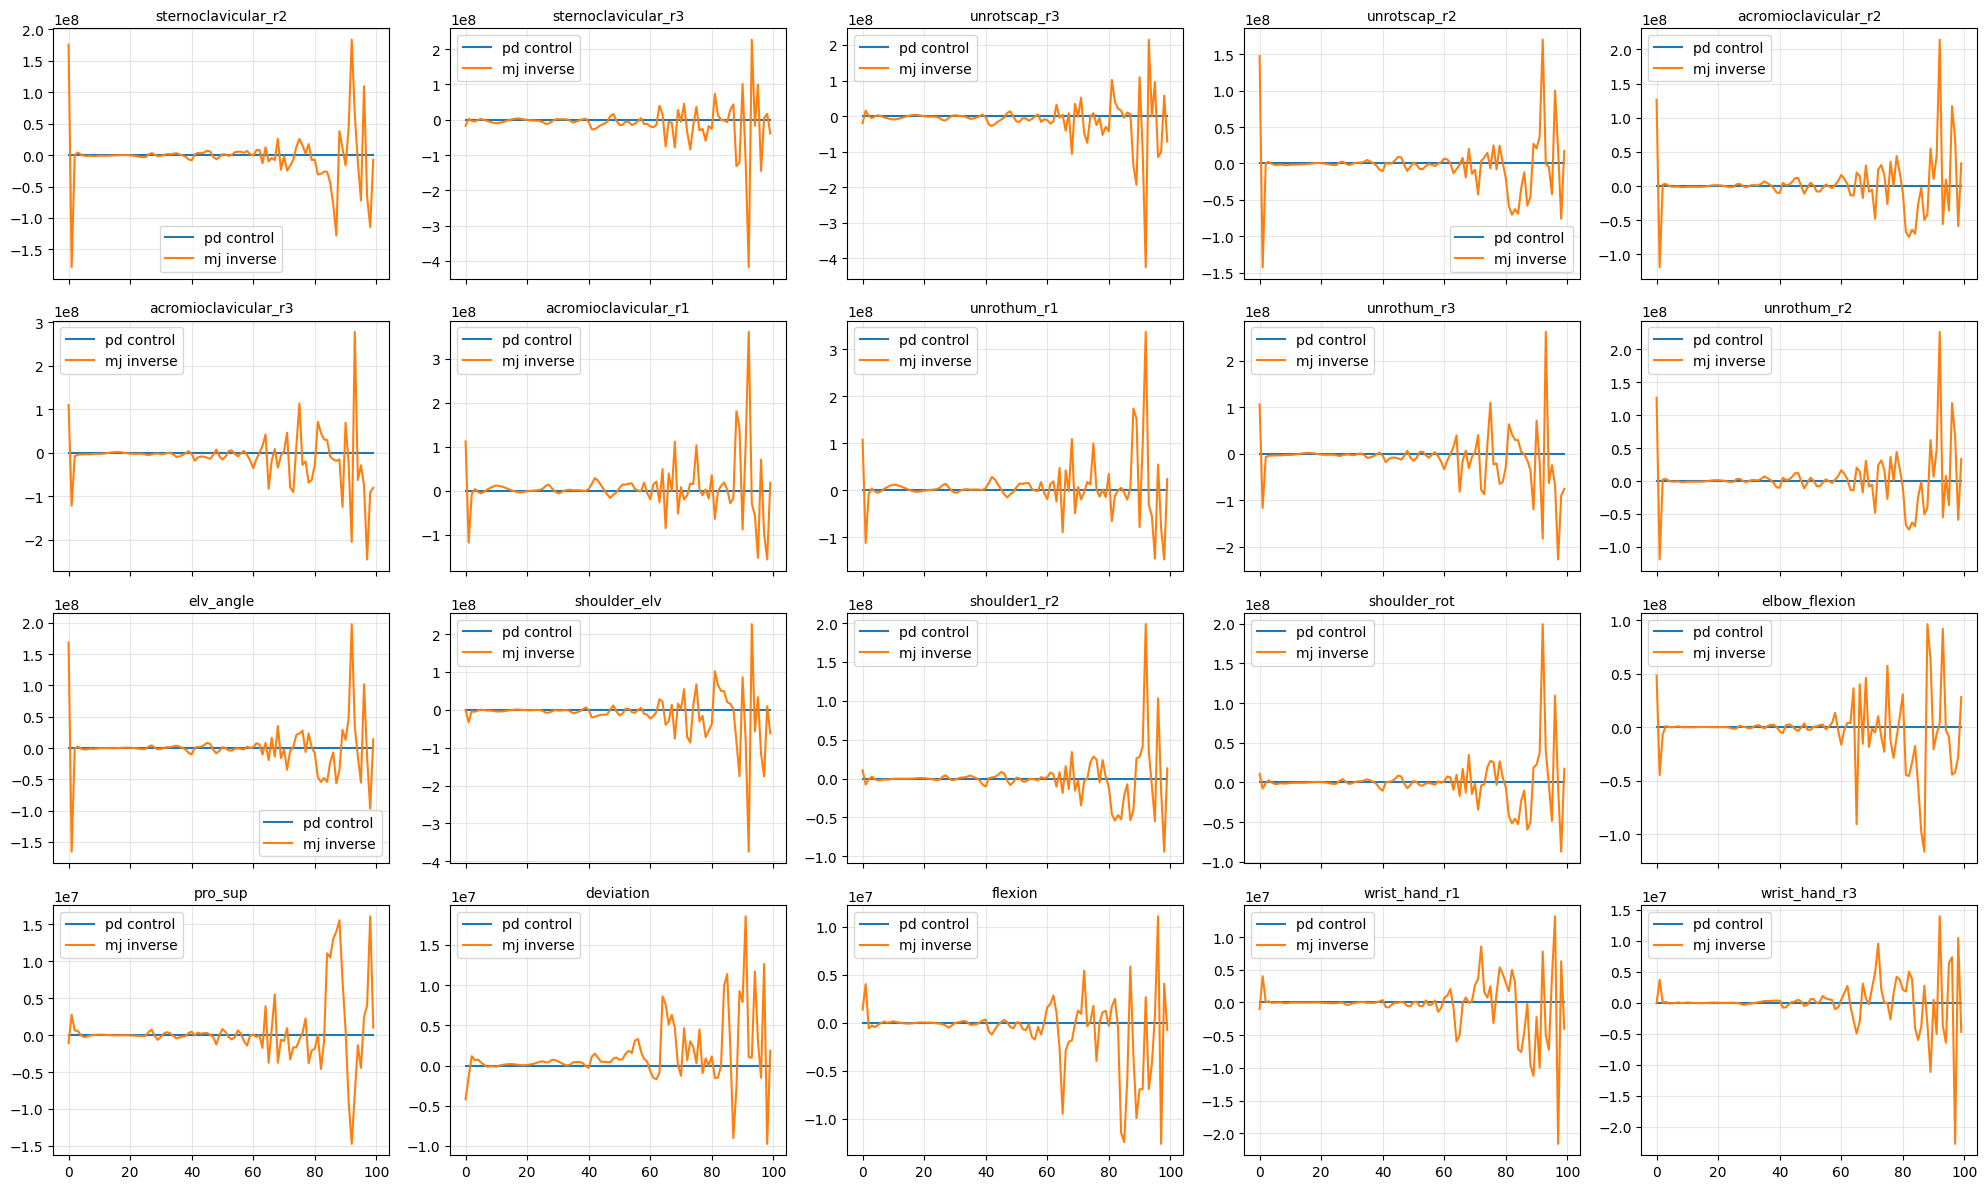

In [16]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(pd_qforces[joint_name], lw=1.5, label = "pd control")
    ax.plot(mj_qforces[joint_name], lw=1.5, label = "mj inverse")
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend()
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()